# Online Gradient Computation in JAX

`models` implements a range of neural network models in JAX.

`OnlineCTRNNCell` implements a CT-RNN with custom gradients for RTRL or RFLO. 

The `FADense` module can be configured to use feedback alignment. 

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')
import numpy as np
from jax_rtrl.models import FADense
import jax
from jax import numpy as jnp
import jax.random as jrand
import optax

import matplotlib.pyplot as plt


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Sinusoidal Toy Dataset

We create a sinusoidal function as a toy dataset. Lets also initialize the model and plot the initial predictions.

In [2]:
key = jrand.PRNGKey(0)
key, key_model, key_data, key_train = jrand.split(key, 4)
x = np.linspace(0, 5*np.pi, 1000)[:, None]
y = np.sin(x) + 2

(1, 1)


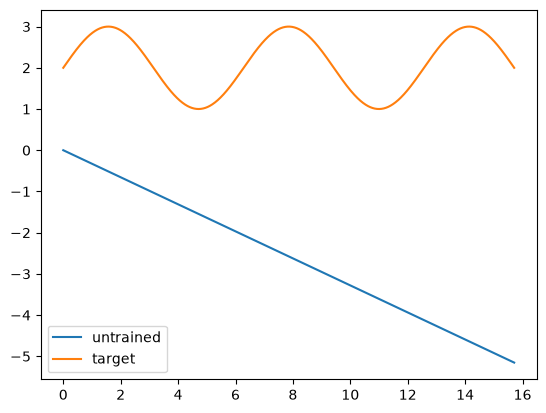

In [3]:
model = FADense(x.shape[-1])
params = model.init(key_model, x)
print(params["params"]["kernel"].shape)
untrained_output = model.apply(params, x).squeeze()

plt.plot(x, untrained_output, label='untrained')
plt.plot(x, y, label='target')
plt.legend()

### Linear Model
Next, we define a loss function and compute the loss of the untrained model.

In [4]:
def loss_fn(_params, __x, __y):
    # MSE loss
    y_hat = model.apply(_params,__x)
    return jnp.mean((y_hat - __y)**2)

loss_fn(params, x, y)

Array(24.826553, dtype=float32)

Now we can train the model and plot the result.

In [5]:
def print_progress(i, loss):
    if i % 1000 == 0:
        print(f'Iteration {i} | Loss: {loss:.3f}')

def train(params, data, key, num_steps=10_000, lr=1e-2, batch_size=256):
    # We use Stochastic Gradient Descent with a constant learning rate
    _x, _y = data
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    def step(carry, n):
        _params, _opt_state, _key = carry
        _key, key_batch = jrand.split(_key)
        batch = jrand.choice(key_batch, np.hstack([_x, _y]), (batch_size,))
        current_loss, grads = jax.value_and_grad(loss_fn)(_params, batch[:,:1], batch[:,1:2])
        updates, _opt_state = optimizer.update(grads, _opt_state, _params)
        _params = optax.apply_updates(_params, updates)
        jax.debug.callback(print_progress, n, current_loss)
        return (_params, _opt_state, _key), current_loss
    (params, *_), losses = jax.lax.scan(step, (params, opt_state, key), np.arange(num_steps, dtype=np.int32))
    print(f'Final loss: {losses[-1]:.3f}')
    return params, losses


Iteration 0 | Loss: 26.198
Iteration 1000 | Loss: 0.502
Iteration 2000 | Loss: 0.475
Iteration 3000 | Loss: 0.454
Iteration 4000 | Loss: 0.499
Iteration 5000 | Loss: 0.520
Iteration 6000 | Loss: 0.477
Iteration 7000 | Loss: 0.541
Iteration 8000 | Loss: 0.450
Iteration 9000 | Loss: 0.498
Final loss: 0.464


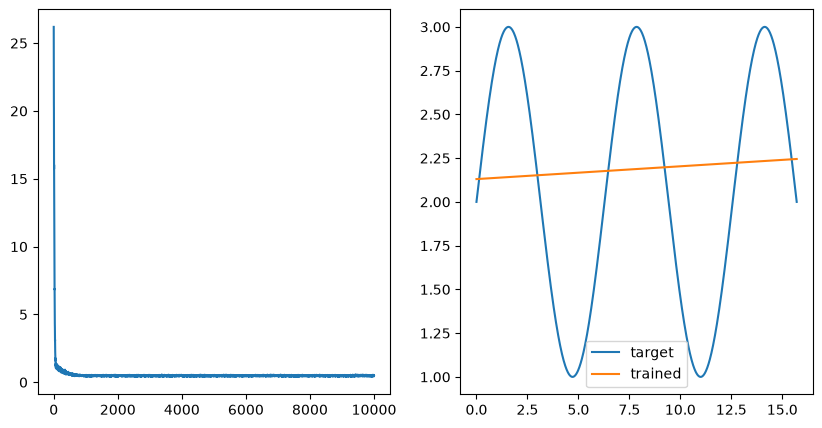

In [6]:
key, key_train = jrand.split(key_data)
params, losses = train(params, (x, y), key)

plt.figure(figsize=(10, 5))

# Plot the training loss
plt.subplot(1, 2, 1)
plt.plot(losses)

# Plot the trained model output
plt.subplot(1, 2, 2)
y_hat = model.apply(params, x)
plt.plot(x, y, label='target')
plt.plot(x, y_hat, label='trained')
plt.legend()

### RNN Model
Since the model is Linear it cannot fit the sinusoidal function. Let's instead use an RNN with a single hidden layer.

In [7]:
from flax import linen as nn
from jax_rtrl.models.cells import OnlineCTRNNCell
from jax_rtrl.models.cells.ctrnn import clip_tau
from jax_rtrl.supervised.training_utils import train_rnn_online
from jax_rtrl.supervised.training_utils import predict

class Model(nn.Module):
    output_size: int = 1
    
    def setup(self):
        self.rnn = OnlineCTRNNCell(16, name="rnn")
        
    def initialize_carry(self, rng, input_shape):
        return self.rnn.initialize_carry(rng, input_shape)
    
    @nn.compact
    def __call__(self, _x, carry, *args):
        carry, _x = self.rnn(_x, carry, *args)
        _x = FADense(self.output_size)(_x)
        return carry, _x


model = Model()
params = model.init(key_model, None, x[0])
state = model.apply(params, key_model, x[0].shape, method=model.initialize_carry)


def loss_fn(_params, __x, __y, carry):
    # MSE loss
    carry, y_hat = model.apply(_params, carry, __x)
    return jnp.mean((y_hat - __y)**2), carry

Train the model

Iteration 0 | Loss: 2.076:   0%|          | 10/2000 [00:00<00:33, 59.95it/s]

Tracing run_episode.
u shape: (16,)


Iteration 1990 | Loss: 0.007: 100%|██████████| 2000/2000 [00:07<00:00, 285.36it/s]

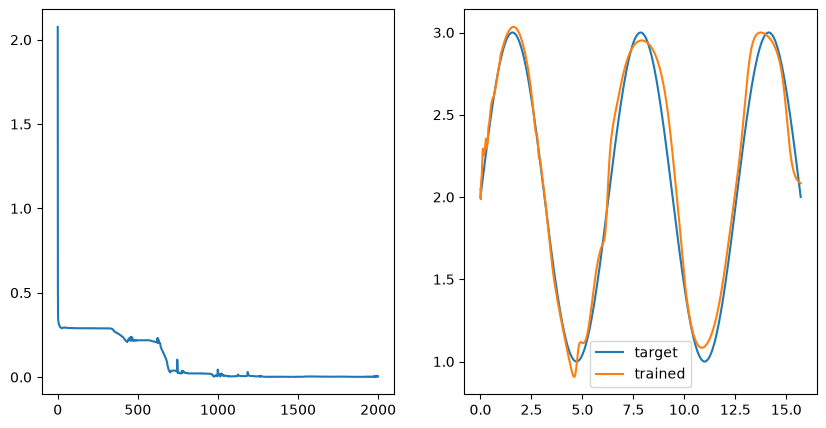

In [8]:
key, key_train = jrand.split(key_data)
optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(1e-4))
params, losses = train_rnn_online(
    loss_fn,
    optimizer,
    params,
    (x, y),
    key_train,
    state,
    num_steps=2e3,
    batched=False,
)


plt.figure(figsize=(10, 5))

# Plot the training loss
plt.subplot(1, 2, 1)
plt.plot(losses)

# Plot the trained model output
plt.subplot(1, 2, 2)
y_hat = predict(model, params, None, x)
plt.plot(x, y, label="target")
plt.plot(x, y_hat, label="trained")
plt.legend()

## Two spirals dataset

(5, 20, 2) (5,)
Spiral directions
Spiral #1: counter-clockwise
Spiral #2: counter-clockwise
Spiral #3: clockwise
Spiral #4: clockwise
Spiral #5: clockwise


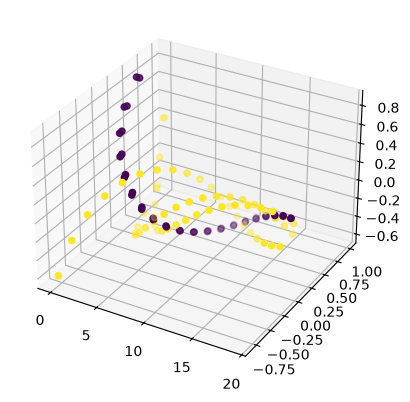

In [ ]:
from jax_rtrl.supervised.example_datasets import spirals
import numpy as np

x_test, y_test = spirals(dataset_size=5, time=30, key=key_data)
print(x_test.shape, y_test.shape)
print("Spiral directions")
for i in range(y_test.shape[0]):
    print(f"Spiral #{i+1}: {"clockwise" if y_test[i] == 1 else "counter-clockwise"}")
def plot_spirals(x, y):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    for t in range(x.shape[1]):
        if y.ndim == 2:
            ax.scatter(t, x[:, t, 0], x[:, t, 1], c=y[:, t])
        else:
            ax.scatter(t, x[:, t, 0], x[:, t, 1], c=y)
plot_spirals(x_test, y_test)

Let's see how our model performs on the more complex dataset.

(1500, 2) (1500, 1) (1500, 1)


  0%|          | 0/1000 [00:00<?, ?it/s]

Tracing run_episode.
u shape: (16,)


Iteration 990 | Loss: 0.031: 100%|██████████| 1000/1000 [00:05<00:00, 186.18it/s]


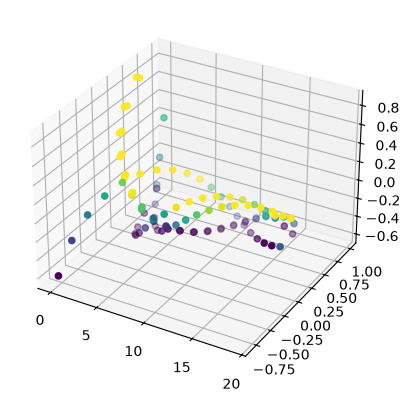

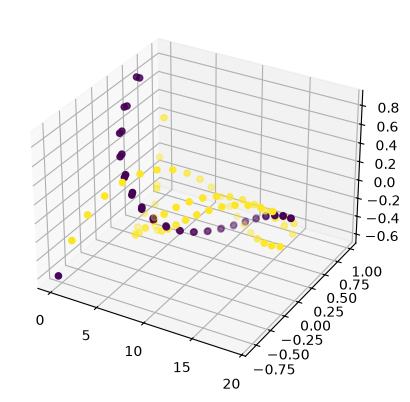

In [18]:
from jax_rtrl.models.seq_models import scan_rnn

x, y = spirals(dataset_size=50, time=30, key=key_data)
repeated_y = np.repeat(y[:, None], x.shape[1], axis=1)
# Unstack x and y to feed them one by one to the RNN
# Dones for marking the trajectory bounds
dones = np.zeros_like(repeated_y)
dones[:, 0] = 1
y_seq = np.reshape(repeated_y, (-1, 1))
dones = np.reshape(dones, (-1, 1))
x_seq = np.reshape(x, (-1, x.shape[-1]))

params = model.init(key_model, None, x[0, 0])
state = model.apply(
    params, key_model, (x_test.shape[0], x_test.shape[2]), method=model.initialize_carry
)
untrained_output = scan_rnn(model, params, x_test, init_carry=state, batched=True)[1]
plot_spirals(x_test, jax.nn.sigmoid(untrained_output[..., 0]))

def loss_fn(_params, _x, _y, carry):
    # BCE loss
    carry, y_hat = model.apply(_params, carry, _x)
    bce_loss = optax.sigmoid_binary_cross_entropy(y_hat, _y)
    return bce_loss.mean(), carry


print(x_seq.shape, dones.shape, y_seq.shape)
state_train = model.apply(
    params, key_model, (x_seq.shape[-1:]), method=model.initialize_carry
)
params, losses = train_rnn_online(
    loss_fn,
    optimizer,
    params,
    (x_seq, y_seq),
    key_train,
    state_train,
    dones,
    num_steps=1e3,
    batched=False,
)

trained_output = scan_rnn(model, params, x_test, init_carry=state, batched=True)[1]
labels = jax.nn.sigmoid(trained_output)
plot_spirals(x_test, labels[..., 0])